In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

def get_base_dir():
    # In a script, __file__ exists; in notebooks it doesn't
    if '__file__' in globals():
        return os.path.dirname(os.path.abspath(__file__))
    else:
        return os.getcwd()

def calculate_marginal_median_and_mad(samples, bins='auto'):
    """
    Per-parameter marginal median and MAD, in a loop style matching
    `calculate_marginal_peak_and_mad`. The `bins` argument is accepted
    for API symmetry but not used.
    """
    # keep the arg to avoid linters complaining it's unused
    _ = bins

    nwalkers, nsteps, ndim = samples.shape
    flat = samples.reshape(-1, ndim)

    medians = np.empty(ndim, dtype=float)
    mads    = np.empty(ndim, dtype=float)

    for i in range(ndim):
        data = flat[:, i]
        medians[i] = np.median(data)
        mads[i]    = np.median(np.abs(data - medians[i]))

    return medians, mads


def calculate_marginal_peak_and_mad(samples, bins='auto'):
    nwalkers, nsteps, ndim = samples.shape
    flat = samples.reshape(-1, ndim)

    peaks = np.empty(ndim)
    mads  = np.empty(ndim)

    for i in range(ndim):
        data = flat[:, i]

        # 1) Histogram-based mode estimate
        hist, edges = np.histogram(data, bins=bins, density=True)
        # find the bin with maximum density
        idx_peak = np.argmax(hist)
        # mode ≈ midpoint of that bin
        peaks[i] = 0.5*(edges[idx_peak] + edges[idx_peak+1])

        # 2) MAD around the mode
        mads[i] = np.median(np.abs(data - peaks[i]))

    return peaks, mads

def plot_triangle_one(samples, param_names, label,
                      output_folder, plot_name, marker=True):
    mcs = MCSamples(samples=samples, names=param_names, label=label)
    g = plots.getSubplotPlotter(width_inch=8)
    g.settings.title_limit_fontsize = 14
    g.settings.axes_fontsize = 14
    g.settings.axes_labelsize = 14

    g.triangle_plot(
        [mcs], param_names,
        filled=True,
        contour_colors=['#4169E1'],
        contour_lws=[1.5],
        alpha=0.6
    )

    if marker:
        medians, mads = calculate_marginal_median_and_mad(samples, bins='auto')
        for i, x0 in enumerate(medians):
            ax = g.subplots[i, i]
            ax.axvline(x0, color='k', ls='--')
            ax.set_title(f"{param_names[i]} = {medians[i]:.3f}±{mads[i]:.3f}",
                         fontsize=12)

    os.makedirs(output_folder, exist_ok=True)
    plt.savefig(os.path.join(output_folder, plot_name),
                bbox_inches='tight', dpi=200)
    plt.show()

In [4]:
def _normalize_pairs(evo_labels, prior_labels):
    """
    Accept either:
      - evo_labels: list[str], prior_labels: list[str] of same length
      - evo_labels: list[tuple[str,str]] and prior_labels: None/[]
    Returns: list of (evo, prior)
    """
    if prior_labels is None or len(prior_labels) == 0:
        # expect evo_labels to be list of tuples
        pairs = list(evo_labels)
    else:
        if len(evo_labels) != len(prior_labels):
            raise ValueError("evo_labels and prior_labels must have the same length.")
        pairs = list(zip(evo_labels, prior_labels))
    return pairs

def _default_colors(n):
    # Use Matplotlib's tab10 cycle repeatedly if needed
    base = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
    if not base:
        base = [f"C{i}" for i in range(10)]
    colors = [base[i % len(base)] for i in range(n)]
    return colors

def _sanitize_param_labels(param_names):
    """
    GetDist expects LaTeX fragments WITHOUT surrounding $...$.
    This removes any $ so '$\\Omega_k$' -> '\\Omega_k'.
    """
    cleaned = []
    for s in param_names:
        if s is None:
            cleaned.append("")
            continue
        s = str(s).strip().replace("$", "")
        cleaned.append(s)
    return cleaned


# ----------------------- plotting -----------------------

def plot_triangle_multi(
    base_dir,
    param_names,               # e.g. [r'$\Omega_k$', r'$w$']  (dollars allowed; we'll sanitize)
    evo_labels,
    prior_labels=None,
    output_folder=None,
    legend_list=None,
    plot_name="triangle_multi.png",
    bins='auto',
    filled=True,
    add_markers=True,
    colors=None,
    dpi=220,
    axis_labels=None,          # NEW: optional override for axis labels (LaTeX fragments, no $)
):
    pairs = _normalize_pairs(evo_labels, prior_labels)
    ndim = len(param_names)

    # Internal parameter codes that GetDist will use to reference params
    param_codes = [f"p{i}" for i in range(ndim)]

    # --- labels to show on axes ---
    # If user provides axis_labels, use them; otherwise sanitize param_names
    if axis_labels is not None:
        if len(axis_labels) != ndim:
            raise ValueError("axis_labels must have same length as param_names.")
        labels_show = _sanitize_param_labels(axis_labels)
    else:
        labels_show = _sanitize_param_labels(param_names)

    mcs_list = []
    legend_labels = []
    peak_mad_list = []

    for evo, prior in pairs:
        folder = os.path.join(base_dir, "Output", f"{evo}-{prior}")
        fname  = os.path.join(folder, f"mcmc_cosmop{ndim}D-{evo}-{prior}.npy")
        if not os.path.isfile(fname):
            raise FileNotFoundError(f"Missing samples file: {fname}")

        arr = np.load(fname)  # (nwalkers, nsteps, ndim)
        if arr.ndim != 3 or arr.shape[-1] != ndim:
            raise ValueError(
                f"Samples in {fname} have shape {arr.shape}, expected (*, *, {ndim})."
            )

        flat = arr.reshape(-1, ndim)
        label = f"{evo}_{prior}"

        # IMPORTANT: names=param_codes, labels=labels_show (NO $)
        mcs = MCSamples(samples=flat, names=param_codes, labels=labels_show, label=label)
        mcs_list.append(mcs)
        # legend_labels.append(label)
        legend_labels=legend_list

        peak_mad_list.append(calculate_marginal_peak_and_mad(arr, bins=bins))

    if colors is None:
        colors = _default_colors(len(mcs_list))

    g = plots.getSubplotPlotter(width_inch=8)
    # Slightly larger labels/ticks for readability
    g.settings.axes_labelsize = 20
    g.settings.axes_fontsize  = 20
    g.settings.legend_fontsize = 16
    g.settings.title_limit_fontsize = 14
    # Ensure LaTeX is used for labels; GetDist handles it when labels lack $...$

    # Use param_codes here (NOT the LaTeX with $)
    g.triangle_plot(
        mcs_list,
        param_codes,
        filled=filled,
        alpha = 0.5,
        contour_colors=colors,
        contour_ls=['-'] * len(mcs_list),
        contour_lws=[1.5] * len(mcs_list),
        legend_labels=legend_labels,
        legend_loc='upper right'
    )

    # if add_markers:
    #     for i in range(ndim):
    #         ax = g.subplots[i, i]
    #         for j, (peaks, mads) in enumerate(peak_mad_list):
    #             ax.axvline(peaks[i], ls='--', lw=1.0, color=colors[j], alpha=0.9)
    #         # Use sanitized label in the title, wrap with $ here only
    #         lbl = labels_show[i]
    #         peaks0, mads0 = peak_mad_list[0]
    #         ax.set_title(f"${lbl}$ = {peaks0[i]:.3f}±{mads0[i]:.3f}", fontsize=12)

    if output_folder is None:
        output_folder = os.path.join(base_dir, "Results")
    os.makedirs(output_folder, exist_ok=True)
    outpath = os.path.join(output_folder, plot_name)
    plt.savefig(outpath, bbox_inches='tight', dpi=dpi)
    plt.show()
    # print(f"Saved: {outpath}")



Removed no burn in
Removed no burn in


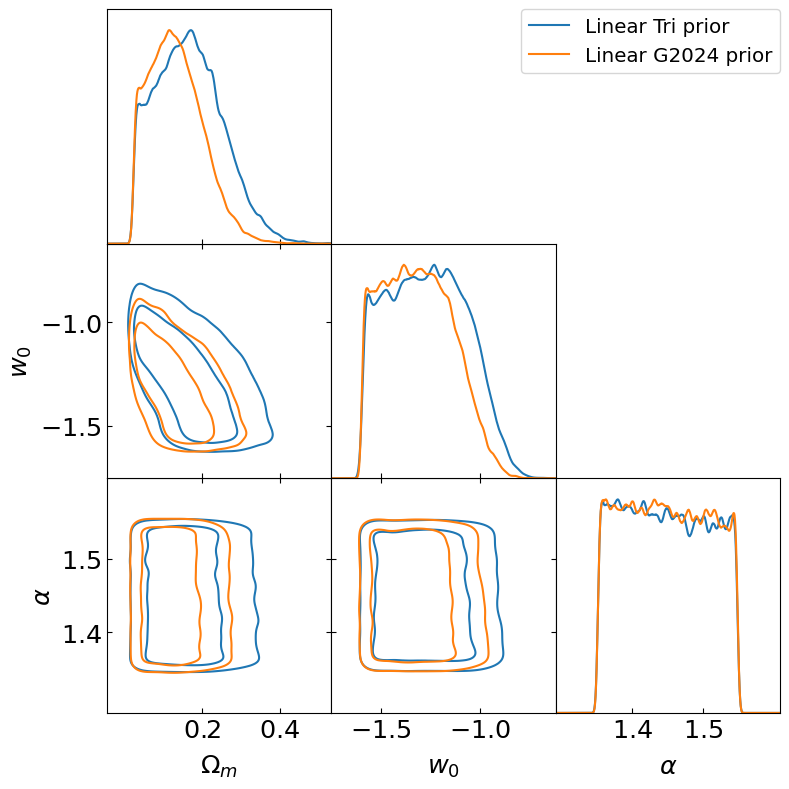

In [5]:
if __name__ == "__main__":
    base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
    param_names = [r'$\Omega_m$', r'$w_0$', r'$\alpha$']

    # Option A: two parallel lists
    evo_list   = ["linear", "linear"]
    prior_list = ["wphi-Tri", "wphi-0.22"]

    plot_triangle_multi(
        base_dir=base_dir,
        param_names=param_names,
        evo_labels=evo_list,
        prior_labels=prior_list,
        output_folder=os.path.join(base_dir, "Results"),
        legend_list=[r'Linear Tri prior', r'Linear G2024 prior'],
        plot_name="triangle_3D_multi_linear_wphiCDM.png",
        filled=False,
        add_markers=True
    )

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from getdist import plots, MCSamples

def _weighted_quantile_1d(x, q, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.quantile(x, q)
    w = np.asarray(w, float)
    s = np.argsort(x)
    xs, ws = x[s], w[s]
    cdf = np.cumsum(ws) / np.sum(ws)
    return np.interp(q, cdf, xs)

def calculate_marginal_median_and_mad_weighted(samples, weights=None, scale=1.4826):
    """
    samples:
      encourages either
        - 2D: (nsamp, ndim)
        - 3D: (nwalkers, nsteps, ndim)
    weights (optional):
        - None
        - 1D: (nsamp,)
        - 2D: (nwalkers, nsteps)
    """
    arr = np.asarray(samples)
    if arr.ndim == 3:
        nwalkers, nsteps, ndim = arr.shape
        flat = arr.reshape(-1, ndim)
        if weights is not None:
            w = np.asarray(weights, float)
            if w.shape == (nwalkers, nsteps):
                w = w.reshape(-1)
            elif w.shape == (nwalkers * nsteps,):
                pass
            else:
                raise ValueError("3D samples: weights must be (nwalkers,nsteps) or flattened (nwalkers*nsteps,)")
        else:
            w = None

    elif arr.ndim == 2:
        nsamp, ndim = arr.shape
        flat = arr
        if weights is not None:
            w = np.asarray(weights, float)
            if w.shape == (nsamp,):
                pass
            else:
                raise ValueError("2D samples: weights must be (nsamp,) or None")
        else:
            w = None

    else:
        raise ValueError(f"samples must be 2D or 3D, got shape {arr.shape}")

    medians = np.empty(ndim, dtype=float)
    mads    = np.empty(ndim, dtype=float)
    for i in range(ndim):
        xi  = flat[:, i]
        med = _weighted_quantile_1d(xi, 0.5, w)
        mad = _weighted_quantile_1d(np.abs(xi - med), 0.5, w) * scale
        medians[i] = med
        mads[i]    = mad
    return medians, mads

def _strip_outer_dollars(s: str) -> str:
    s = str(s).strip()
    if len(s) >= 2 and s[0] == '$' and s[-1] == '$':
        return s[1:-1]
    return s

def _as_2d_samples(samples):
    """
    Accepts samples with shape:
      - (nsamp, ndim)
      - (nwalkers, nsteps, ndim)
    Returns: flat_2d (nsamp_flat, ndim), ndim
    """
    arr = np.asarray(samples)
    if arr.ndim == 2:
        flat = arr
    elif arr.ndim == 3:
        nwalkers, nsteps, ndim = arr.shape
        flat = arr.reshape(nwalkers * nsteps, ndim)
    else:
        raise ValueError(f"samples must be 2D or 3D, got shape {arr.shape}")
    if flat.shape[1] < 1:
        raise ValueError(f"ndim must be >= 1, got {flat.shape[1]}")
    return flat, flat.shape[1]

def plot_triangle_one(samples, param_names=None, label="",
                      output_folder=".", plot_name="triangle.png",
                      marker=True, legend_text="strong lensing distance ratio"):
    """
    Auto-detects input samples dimensionality:
      - if samples is (nwalkers, nsteps, ndim): flattens to (nwalkers*nsteps, ndim)
      - if samples is (nsamp, ndim): uses as-is

    param_names:
      - None  -> auto-generate names p0..p{ndim-1}
      - list length < ndim -> uses first len(list) dimensions
      - list length == ndim -> uses all
    """
    flat, ndim_all = _as_2d_samples(samples)

    # Determine which dims to plot
    if param_names is None:
        names = [f"p{i}" for i in range(ndim_all)]
        labels = [f"p{i}" for i in range(ndim_all)]
        flat_use = flat
    else:
        if not isinstance(param_names, (list, tuple)):
            raise ValueError("param_names must be a list/tuple or None")
        k = len(param_names)
        if k == 0:
            raise ValueError("param_names cannot be empty")
        if k > ndim_all:
            raise ValueError(f"param_names length ({k}) > ndim in samples ({ndim_all})")
        # Use first k dimensions if fewer names are provided
        flat_use = flat[:, :k]
        names = [f"p{i}" for i in range(k)]          # internal names for getdist
        labels = list(param_names)                    # display labels (can be LaTeX)

    # Create getdist samples
    mcs = MCSamples(samples=flat_use, names=param_names, label=label)

    g = plots.getSubplotPlotter(width_inch=8)
    g.settings.title_limit_fontsize = 14
    g.settings.axes_fontsize = 14
    g.settings.axes_labelsize = 14

    contour_color = '#4169E1'
    g.triangle_plot(
        [mcs], param_names,
        filled=True,
        contour_colors=[contour_color],
        contour_lws=[1.5],
        alpha=0.6
    )

    # Optional: median + MAD markers on diagonal
    if marker:
        medians, mads = calculate_marginal_median_and_mad_weighted(flat_use, weights=None, scale=1.4826)
        for i, x0 in enumerate(medians):
            ax = g.subplots[i, i]
            ax.axvline(x0, color='k', ls='--')
            ax.set_title(rf"{param_names[i]} = {medians[i]:.3f}±{mads[i]:.3f}", fontsize=12)


    # Global legend
    proxy = Line2D([0], [0], color=contour_color, lw=2)
    g.fig.legend(handles=[proxy], labels=[legend_text],
                 loc='upper right', frameon=False, fontsize=12)

    os.makedirs(output_folder, exist_ok=True)
    plt.savefig(os.path.join(output_folder, plot_name), bbox_inches='tight', dpi=200)
    plt.show()




Removed no burn in


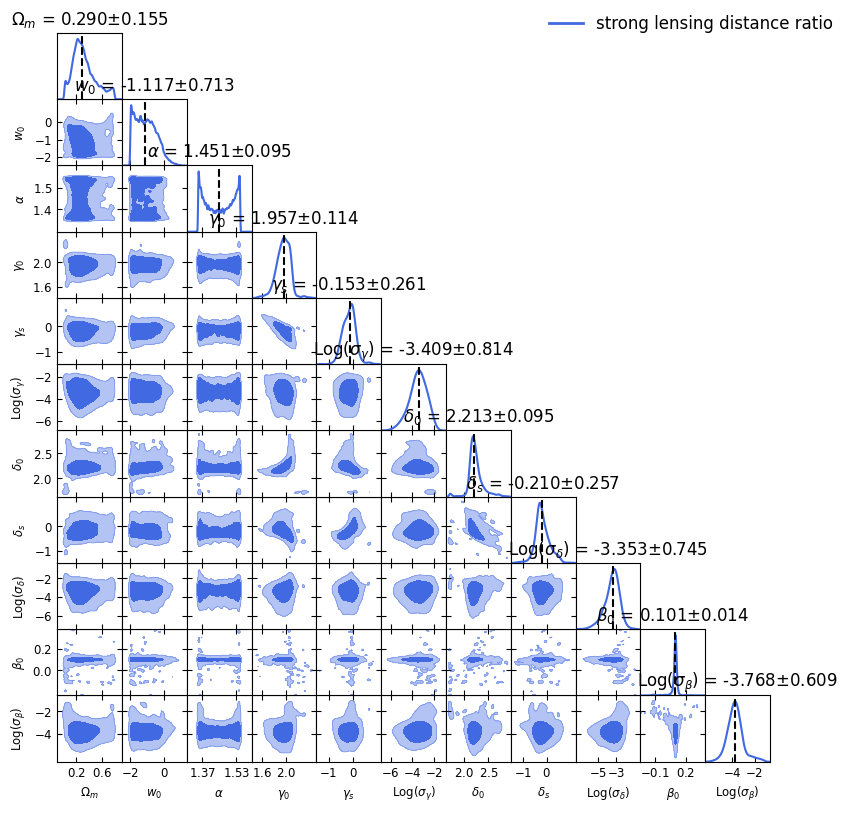

In [30]:
base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
evo_label = r"fullhier-ann"
prior_label = r"gaussian-hier-wphi-tri"

# 1) Four parameter names in LaTeX
param_names = [r'$\Omega_m$', r'$w_0$', r'$\alpha$']

# 2) Load the single chain from relative path
samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop494D-{evo_label}-{prior_label}.npy")
samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

samples3 = np.load(samples_file)                 # (nwalkers, nsteps, 493)
nwalkers, nsteps, ndim = samples3.shape

burn = int(0.1 * nsteps)                         # 自己调
flat = samples3[:, burn:, :].reshape(-1, ndim)   # (Nsamples, 493)

cosmo = flat[:, :11]     

plot_triangle_one(
    samples=cosmo,
    param_names=[r'$\Omega_m$', r'$w_0$', r'$\alpha$',
                 r'$\gamma_0$',r'$\gamma_s$',r'$\mathrm{Log}(\sigma_{\gamma})$',
                 r'$\delta_0$',r'$\delta_s$',r'$\mathrm{Log}(\sigma_{\delta})$',
                 r'$\beta_0$',r'$\mathrm{Log}(\sigma_{\beta}$)'],   # 只给两个名字 -> 自动取前两维
    label=f'{evo_label}_{prior_label}',
    output_folder=os.path.join(base_dir, 'Results'),
    plot_name=f'triangle_11D_{evo_label}-{prior_label}_wphiCDM.png',
    marker=True
)

Removed no burn in


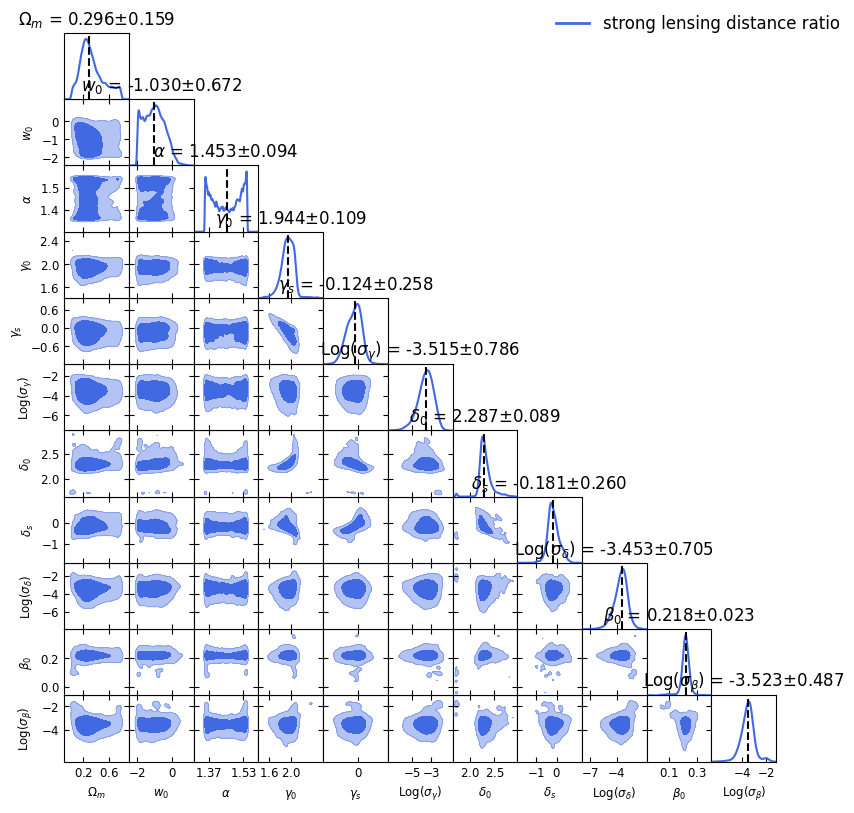

In [31]:
base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
evo_label = r"fullhier-ann"
prior_label = r"gaussian-hier-wphi-gauss"

# 1) Four parameter names in LaTeX
param_names = [r'$\Omega_m$', r'$w_0$', r'$\alpha$']

# 2) Load the single chain from relative path
samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop494D-{evo_label}-{prior_label}.npy")
samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

samples3 = np.load(samples_file)                 # (nwalkers, nsteps, 493)
nwalkers, nsteps, ndim = samples3.shape

burn = int(0.1 * nsteps)                         # 自己调
flat = samples3[:, burn:, :].reshape(-1, ndim)   # (Nsamples, 493)

cosmo = flat[:, :11]     

plot_triangle_one(
    samples=cosmo,
    param_names=[r'$\Omega_m$', r'$w_0$', r'$\alpha$',
                 r'$\gamma_0$',r'$\gamma_s$',r'$\mathrm{Log}(\sigma_{\gamma})$',
                 r'$\delta_0$',r'$\delta_s$',r'$\mathrm{Log}(\sigma_{\delta})$',
                 r'$\beta_0$',r'$\mathrm{Log}(\sigma_{\beta}$)'],   # 只给两个名字 -> 自动取前两维
    label=f'{evo_label}_{prior_label}',
    output_folder=os.path.join(base_dir, 'Results'),
    plot_name=f'triangle_11D_{evo_label}-{prior_label}_wphiCDM_gauss.png',
    marker=True
)

Removed no burn in
Removed no burn in
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
Removed no burn in


Removed no burn in


Removed no burn in
Saved plot: wphi_omegam_w0_SL_and_joint.png


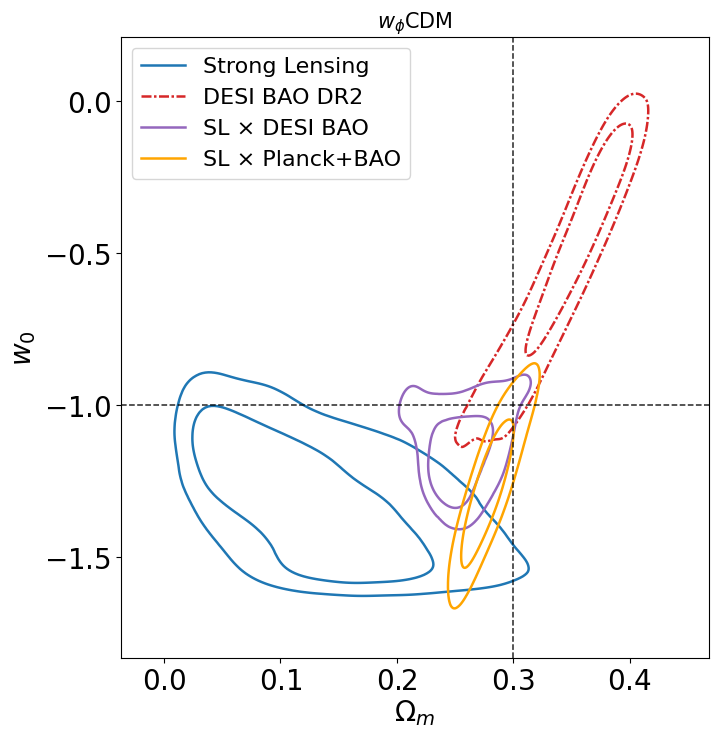

In [18]:
# pip install getdist matplotlib scipy
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from getdist.mcsamples import MCSamples, loadMCSamples
from getdist import plots
from scipy.stats import gaussian_kde

# ====================== 基础路径（按需修改） ======================
base_dir       = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
local_pairs    = [("linear", "wphi-0.22")]   # 本地 3D 链（含 omegam, w0, wa）
local_col_idx  = {'omegam': 0, 'w0': 1, 'wa': 2}
burnin_frac    = 0.30

# DESI BAO (常见文本链，含 omegam / w0)
desi_bao_folder = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/DESI_BAO_base_w_wa/desi-bao-all"

# Planck+BAO（CosmoMC/GetDist 样式根路径）
planck_base_dir   = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data"
planck_base_label = "base_w_wa"
planck_root_bao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE_BAO",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE_BAO"
)

# ====================== 工具函数 ======================
def numpy3d_to_mcsamples_Om_w0(arr, burnin_frac=0.3, col_idx=None, label=None):
    """
    从本地 (nwalk, nstep, ndim) 或 (N, ndim) 的数组取出 (omegam, w0) 两列为 MCSamples。
    """
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
    i_om = col_idx['omegam']; i_w0 = col_idx['w0']
    sub  = flat[:, [i_om, i_w0]]
    mcs = MCSamples(samples=sub, names=['omegam','w0'], labels=[r'\Omega_m', r'w_0'])
    if label: mcs.label = label
    return mcs

def _getcol(a, *candidates):
    for name in candidates:
        if name in a.dtype.names:
            return a[name]
    return None

def load_desi_bao_Om_w0(folder, label=r"DESI BAO DR2"):
    """
    读取 DESI BAO 文本链（chain.*.txt），抽取 (omegam, w0)。
    尝试兼容列名别名：omegam/omm/om、w0/w/w_0。
    """
    files = sorted(glob.glob(os.path.join(folder, "chain.*.txt")))
    if not files:
        raise FileNotFoundError("No chain.*.txt found under " + folder)
    parts = [np.genfromtxt(f, names=True, comments="#") for f in files]
    data  = np.concatenate(parts)

    Om  = _getcol(data, 'omegam', 'omm', 'om', 'Omega_m', 'OmegaM')
    w0  = _getcol(data, 'w0', 'w', 'w_0')

    if Om is None or w0 is None:
        raise KeyError("DESI: 需要列 omegam 与 w0（兼容别名：omm/om, w/w_0）。")

    weights = _getcol(data, 'weight','weights','Weight','Weights')
    samples = np.vstack([Om, w0]).T
    gd = MCSamples(samples=samples, names=['omegam','w0'],
                   labels=[r'\Omega_m', r'w_0'],
                   weights=weights if weights is not None else None)
    gd.updateSettings({'ignore_rows': 0.0})
    gd.label = label
    return gd

def ensure_Om_w0(samples):
    """
    Planck 链若字段名不同，统一提供 omegam / w0。
    """
    P = samples.getParams()
    names = {p.name for p in samples.getParamNames().names}
    # Omega_m
    if 'omegam' not in names:
        # 常见名称兼容
        cand = None
        for nm in ['omegam','om','Omega_m','OmegaM','omm']:
            if hasattr(P, nm):
                cand = getattr(P, nm); break
        if cand is None:
            raise RuntimeError("Planck 链中未找到 Ωm（omegam/om/Omega_m 等）。")
        samples.addDerived(cand, name='omegam', label=r'\Omega_m')
    else:
        try: samples.setLabel('omegam', r'\Omega_m')
        except: pass

    # w0
    if 'w0' not in names:
        if hasattr(P, 'w'):
            samples.addDerived(P.w, name='w0', label=r'w_0')
        elif hasattr(P, 'w0'):
            try: samples.setLabel('w0', r'w_0')
            except: pass
        else:
            raise RuntimeError("Planck 链未包含 w0/w。")
    else:
        try: samples.setLabel('w0', r'w_0')
        except: pass
    return samples

def _extract_2d_from_mcs(mcs, xname='omegam', yname='w0'):
    P = mcs.getParams()
    x = getattr(P, xname)
    y = getattr(P, yname)
    return np.vstack([x, y]).T

def make_joint_by_kde_2d(base_mcs, ref_pts, names=('omegam','w0'), label="Joint", bw='scott'):
    """
    用 ref_pts(N,2) 对 base_mcs 的 (x,y) 做 KDE 评估 → 作为权重得到联合后验。
    假设两者对 (x,y) 先验一致或近似均匀；如不一致需在此处做先验校正。
    """
    xname, yname = names
    base_xy = _extract_2d_from_mcs(base_mcs, xname, yname)
    w_base  = base_mcs.weights if base_mcs.weights is not None else np.ones(base_xy.shape[0])

    kde  = gaussian_kde(ref_pts.T, bw_method=bw)
    dens = np.clip(kde(base_xy.T), 1e-300, None)
    w_joint = w_base * dens

    joint = MCSamples(samples=base_xy, names=[xname, yname],
                      labels=[r'\Omega_m', r'w_0'], weights=w_joint)
    joint.label = label
    return joint

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

# ====================== 加载数据 ======================
# 本地 SL（含 omegam, w0, wa）
local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop3D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)
    mcs = numpy3d_to_mcsamples_Om_w0(arr, burnin_frac=burnin_frac, col_idx=local_col_idx,
                                     label=r"Strong Lensing")
    local_mcs.append(mcs)
SL = local_mcs[0]

# DESI BAO（Ωm–w0）
BAO = load_desi_bao_Om_w0(desi_bao_folder, label=r"DESI BAO DR2")

# Planck+BAO（Ωm–w0）
planck_bao = loadMCSamples(planck_root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_bao = ensure_Om_w0(planck_bao)
planck_bao.label = r"Planck+BAO"

# ====================== 联合限制（KDE 重加权） ======================
# 注意：我们用“对方”为 base，把对方在 (Ωm,w0) 的后验点按 SL 的 KDE 作为权重 → 相当于 SL × 对方
SL_pts = _extract_2d_from_mcs(SL, 'omegam', 'w0')

SLxBAO = make_joint_by_kde_2d(
    base_mcs=BAO,
    ref_pts=SL_pts,
    names=('omegam','w0'),
    label=r"SL × DESI BAO",
    bw='scott'
)

SLxPlanckBAO = make_joint_by_kde_2d(
    base_mcs=planck_bao,
    ref_pts=SL_pts,
    names=('omegam','w0'),
    label=r"SL × Planck+BAO",
    bw='scott'
)

# ====================== 绘图（Ωm–w0） ======================
to_plot = [SL, BAO, SLxBAO, SLxPlanckBAO]
legend_labels = [s.label for s in to_plot]

# 样式：SL(蓝实) / BAO(红-. ) / SL×BAO(紫实) / SL×Planck+BAO(橙实)
COL_SL   = '#1f77b4'
COL_BAO  = '#d62728'
COL_SLBAO= '#9467bd'
COL_SLPB = 'orange'

colors    = [COL_SL, COL_BAO, COL_SLBAO, COL_SLPB]
line_args = [
    {'ls': '-',  'lw': 1.8},   # SL
    {'ls': '-.', 'lw': 1.8},   # BAO
    {'ls': '-',  'lw': 1.8},   # SL×BAO
    {'ls': '-',  'lw': 1.8},   # SL×Planck+BAO
]

g = plots.get_subplot_plotter(width_inch=7.2)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 20
g.settings.legend_fontsize = 16

# 画全部不填充的轮廓
g.plot_2d(
    to_plot,
    ['omegam', 'w0'],  # x: Ωm, y: w0
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=None,
)

ax = g.subplots[0, 0]
xlim = auto_limits_multi(to_plot, 'omegam') or (0.15, 0.45)
ylim = auto_limits_multi(to_plot, 'w0')     or (-1.6, -0.6)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$\Omega_m$', fontsize=20)
ax.set_ylabel(r'$w_0$', fontsize=20)
ax.set_title(r'$w_{\phi}$CDM',fontsize=15)

# 参考线：ΛCDM (w0=-1)
ax.axhline(-1.0, ls='--', lw=1.1, color='k', alpha=0.85)
ax.axvline(0.3,  ls='--', lw=1.1, color='k', alpha=0.85)

g.add_legend(legend_labels, legend_loc='upper left', colored_text=False)

out = "wphi_omegam_w0_SL_and_joint.png"
g.export(out)
print(f"Saved plot: {out}")


In [19]:
# === 1D summaries for (omegam, w0, alpha) in wphi scenario ===
import numpy as np
from scipy.stats import gaussian_kde

# ---------- weighted helpers ----------
def _normalize_weights(w):
    if w is None: return None
    w = np.asarray(w, float); s = np.sum(w)
    if s <= 0 or not np.isfinite(s): return None
    return w / s

def _weighted_quantile(x, q, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.quantile(x, q)
    w = np.asarray(w, float)
    s = np.argsort(x)
    xs, ws = x[s], w[s]
    cdf = np.cumsum(ws) / np.sum(ws)
    return np.interp(q, cdf, xs)

def _weighted_quantiles(x, qs, w=None):
    qs = np.atleast_1d(qs).astype(float)
    return np.array([_weighted_quantile(x, q, w) for q in qs])

def _weighted_median(x, w=None):
    return _weighted_quantile(x, 0.5, w)

def _weighted_mad(x, w=None, scale=1.4826):
    med = _weighted_median(x, w)
    return scale * _weighted_median(np.abs(x - med), w)

def _oned_peak(x, w=None, grids=2048):
    x = np.asarray(x, float)
    xmin, xmax = np.min(x), np.max(x)
    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin == xmax:
        return float(np.median(x))
    grid = np.linspace(xmin, xmax, grids)
    kde  = gaussian_kde(x, weights=_normalize_weights(w)) if w is not None else gaussian_kde(x)
    dens = kde(grid)
    return float(grid[np.argmax(dens)])

def _weighted_mean_sigma(x, w=None):
    x = np.asarray(x, float)
    if w is None:
        return float(np.mean(x)), float(np.std(x, ddof=0))
    wn = _normalize_weights(w)
    mu = float(np.sum(wn * x))
    sig = float(np.sqrt(np.sum(wn * (x - mu)**2)))
    return mu, sig

# ---------- alias-aware getters ----------
_ALIAS = {
    'omegam': ['omegam','om','Omega_m','OmegaM','omm'],
    'w0'    : ['w0','w','w_0'],
    'alpha' : ['alpha','a']  # 可按需扩展别名
}

def _get_param_array_with_alias(mcs, target):
    # 先从已注册名里找
    names = [p.name for p in mcs.getParamNames().names]
    if target in names:
        P = mcs.getParams()
        return np.asarray(getattr(P, target), float)
    # 尝试别名
    for alt in _ALIAS.get(target, []):
        if alt in names:
            P = mcs.getParams()
            return np.asarray(getattr(P, alt), float)
    # 兜底：有时属性存在但未在 names 里注册
    P = mcs.getParams()
    for alt in _ALIAS.get(target, []):
        if hasattr(P, alt):
            return np.asarray(getattr(P, alt), float)
    return None

# ---------- summarize & print ----------
def summarize_mcs_1dset(mcs, names=('omegam','w0','alpha')):
    out = {}
    wts = None if mcs.weights is None else np.asarray(mcs.weights, float)
    for nm in names:
        arr = _get_param_array_with_alias(mcs, nm)
        if arr is None:
            out[nm] = None
            continue
        mean, sigma = _weighted_mean_sigma(arr, wts)
        med  = _weighted_median(arr, wts)
        mad  = _weighted_mad(arr, wts)
        pk   = _oned_peak(arr, wts)
        q16, q84 = _weighted_quantiles(arr, [0.16, 0.84], wts)
        out[nm] = dict(
            mean=mean, sigma=sigma,
            median=med, mad=mad,
            peak=pk, q16=q16, q84=q84,
            dmed_minus=med-q16, dmed_plus=q84-med
        )
    return out

def print_summary_1d(tag, summ, names=('omegam','w0','alpha')):
    print(f"\n=== {tag} ===")
    for nm in names:
        s = summ.get(nm, None)
        if s is None:
            print(f"{nm:7s}: (N/A)")
            continue
        peak_txt   = f"peak = {s['peak']:.6f}"
        median_txt = (f"median = {s['median']:.6f} "
                      f"(q16={s['q16']:.6f}, q84={s['q84']:.6f}; "
                      f"Δ-={s['dmed_minus']:.6f}, Δ+={s['dmed_plus']:.6f}) "
                      f"(MAD={s['mad']:.6f})")
        mean_txt   = f"mean = {s['mean']:.6f}, sigma = {s['sigma']:.6f}"
        print(f"{nm:7s}: {peak_txt} | {median_txt} | {mean_txt}")

# ---------- run on your objects ----------
targets = [
    (SL.label,            SL),
    (BAO.label,           BAO),
    (planck_bao.label,    planck_bao),
    (SLxBAO.label,        SLxBAO),
    (SLxPlanckBAO.label,  SLxPlanckBAO),
]
for tag, mcs in targets:
    s = summarize_mcs_1dset(mcs, names=('omegam','w0','alpha'))
    print_summary_1d(tag, s, names=('omegam','w0','alpha'))



=== Strong Lensing ===
omegam : peak = 0.116478 | median = 0.126064 (q16=0.059771, q84=0.201403; Δ-=0.066293, Δ+=0.075339) (MAD=0.072277) | mean = 0.132105, sigma = 0.068210
w0     : peak = -1.310583 | median = -1.322467 (q16=-1.506935, q84=-1.131956; Δ-=0.184468, Δ+=0.190511) (MAD=0.198099) | mean = -1.315480, sigma = 0.169247
alpha  : (N/A)

=== DESI BAO DR2 ===
omegam : peak = 0.371248 | median = 0.358614 (q16=0.318464, q84=0.384235; Δ-=0.040151, Δ+=0.025621) (MAD=0.031270) | mean = 0.351927, sigma = 0.034916
w0     : peak = -0.275285 | median = -0.440097 (q16=-0.775316, q84=-0.206943; Δ-=0.335219, Δ+=0.233155) (MAD=0.280765) | mean = -0.479873, sigma = 0.268407
alpha  : (N/A)

=== Planck+BAO ===
omegam : peak = 0.339102 | median = 0.341583 (q16=0.316073, q84=0.367529; Δ-=0.025510, Δ+=0.025946) (MAD=0.025958) | mean = 0.341667, sigma = 0.025433
w0     : peak = -0.558300 | median = -0.572602 (q16=-0.850358, q84=-0.301379; Δ-=0.277756, Δ+=0.271223) (MAD=0.279101) | mean = -0.577797, 

Removed no burn in
Removed no burn in
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
Removed no burn in
Removed no burn in
Removed no burn in
Saved plot: wphi_omegam_w0_SL_and_joint_hier.png


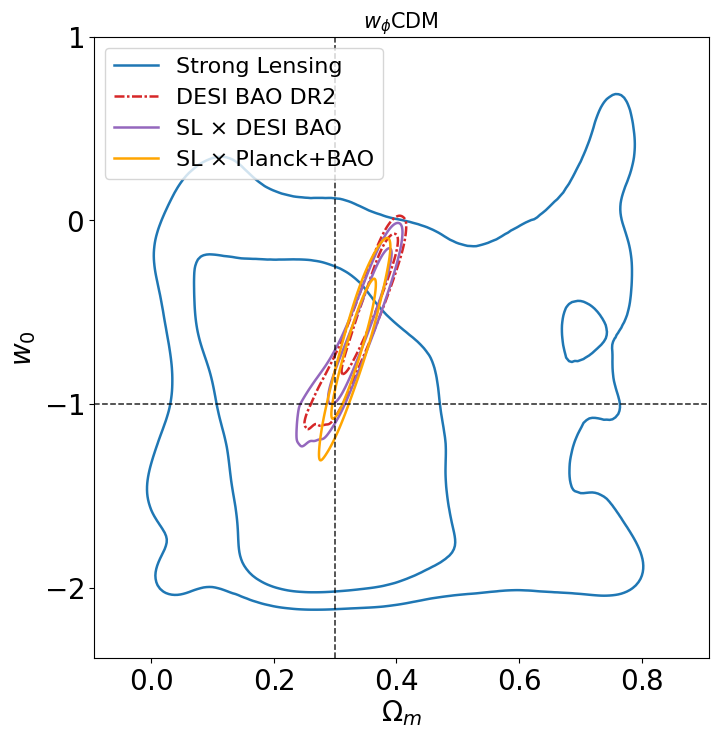

In [33]:
# pip install getdist matplotlib scipy
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from getdist.mcsamples import MCSamples, loadMCSamples
from getdist import plots
from scipy.stats import gaussian_kde

# ====================== 基础路径（按需修改） ======================
base_dir       = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
evo_label = r"fullhier-ann"
prior_label = r"gaussian-hier-wphi-tri"
local_pairs    = [(f'{evo_label}', f'{prior_label}')]   # 本地 3D 链（含 omegam, w0, wa）
local_col_idx  = {'omegam': 0, 'w0': 1, 'alpha': 2}
burnin_frac    = 0.30

# DESI BAO (常见文本链，含 omegam / w0)
desi_bao_folder = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/DESI_BAO_base_w_wa/desi-bao-all"

# Planck+BAO（CosmoMC/GetDist 样式根路径）
planck_base_dir   = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data"
planck_base_label = "base_w_wa"
planck_root_bao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE_BAO",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE_BAO"
)

# ====================== 工具函数 ======================
def numpy3d_to_mcsamples_Om_w0(arr, burnin_frac=0.3, col_idx=None, label=None):
    """
    从本地 (nwalk, nstep, ndim) 或 (N, ndim) 的数组取出 (omegam, w0) 两列为 MCSamples。
    """
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
    i_om = col_idx['omegam']; i_w0 = col_idx['w0']
    sub  = flat[:, [i_om, i_w0]]
    mcs = MCSamples(samples=sub, names=['omegam','w0'], labels=[r'\Omega_m', r'w_0'])
    if label: mcs.label = label
    return mcs

def _getcol(a, *candidates):
    for name in candidates:
        if name in a.dtype.names:
            return a[name]
    return None

def load_desi_bao_Om_w0(folder, label=r"DESI BAO DR2"):
    """
    读取 DESI BAO 文本链（chain.*.txt），抽取 (omegam, w0)。
    尝试兼容列名别名：omegam/omm/om、w0/w/w_0。
    """
    files = sorted(glob.glob(os.path.join(folder, "chain.*.txt")))
    if not files:
        raise FileNotFoundError("No chain.*.txt found under " + folder)
    parts = [np.genfromtxt(f, names=True, comments="#") for f in files]
    data  = np.concatenate(parts)

    Om  = _getcol(data, 'omegam', 'omm', 'om', 'Omega_m', 'OmegaM')
    w0  = _getcol(data, 'w0', 'w', 'w_0')

    if Om is None or w0 is None:
        raise KeyError("DESI: 需要列 omegam 与 w0（兼容别名：omm/om, w/w_0）。")

    weights = _getcol(data, 'weight','weights','Weight','Weights')
    samples = np.vstack([Om, w0]).T
    gd = MCSamples(samples=samples, names=['omegam','w0'],
                   labels=[r'\Omega_m', r'w_0'],
                   weights=weights if weights is not None else None)
    gd.updateSettings({'ignore_rows': 0.0})
    gd.label = label
    return gd

def ensure_Om_w0(samples):
    """
    Planck 链若字段名不同，统一提供 omegam / w0。
    """
    P = samples.getParams()
    names = {p.name for p in samples.getParamNames().names}
    # Omega_m
    if 'omegam' not in names:
        # 常见名称兼容
        cand = None
        for nm in ['omegam','om','Omega_m','OmegaM','omm']:
            if hasattr(P, nm):
                cand = getattr(P, nm); break
        if cand is None:
            raise RuntimeError("Planck 链中未找到 Ωm（omegam/om/Omega_m 等）。")
        samples.addDerived(cand, name='omegam', label=r'\Omega_m')
    else:
        try: samples.setLabel('omegam', r'\Omega_m')
        except: pass

    # w0
    if 'w0' not in names:
        if hasattr(P, 'w'):
            samples.addDerived(P.w, name='w0', label=r'w_0')
        elif hasattr(P, 'w0'):
            try: samples.setLabel('w0', r'w_0')
            except: pass
        else:
            raise RuntimeError("Planck 链未包含 w0/w。")
    else:
        try: samples.setLabel('w0', r'w_0')
        except: pass
    return samples

def _extract_2d_from_mcs(mcs, xname='omegam', yname='w0'):
    P = mcs.getParams()
    x = getattr(P, xname)
    y = getattr(P, yname)
    return np.vstack([x, y]).T

def make_joint_by_kde_2d(base_mcs, ref_pts, names=('omegam','w0'), label="Joint", bw='scott'):
    """
    用 ref_pts(N,2) 对 base_mcs 的 (x,y) 做 KDE 评估 → 作为权重得到联合后验。
    假设两者对 (x,y) 先验一致或近似均匀；如不一致需在此处做先验校正。
    """
    xname, yname = names
    base_xy = _extract_2d_from_mcs(base_mcs, xname, yname)
    w_base  = base_mcs.weights if base_mcs.weights is not None else np.ones(base_xy.shape[0])

    kde  = gaussian_kde(ref_pts.T, bw_method=bw)
    dens = np.clip(kde(base_xy.T), 1e-300, None)
    w_joint = w_base * dens

    joint = MCSamples(samples=base_xy, names=[xname, yname],
                      labels=[r'\Omega_m', r'w_0'], weights=w_joint)
    joint.label = label
    return joint

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

# ====================== 加载数据 ======================
# 本地 SL（含 omegam, w0, wa）
local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop494D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)
    mcs = numpy3d_to_mcsamples_Om_w0(arr, burnin_frac=burnin_frac, col_idx=local_col_idx,
                                     label=r"Strong Lensing")
    local_mcs.append(mcs)
SL = local_mcs[0]

# DESI BAO（Ωm–w0）
BAO = load_desi_bao_Om_w0(desi_bao_folder, label=r"DESI BAO DR2")

# Planck+BAO（Ωm–w0）
planck_bao = loadMCSamples(planck_root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_bao = ensure_Om_w0(planck_bao)
planck_bao.label = r"Planck+BAO"

# ====================== 联合限制（KDE 重加权） ======================
# 注意：我们用“对方”为 base，把对方在 (Ωm,w0) 的后验点按 SL 的 KDE 作为权重 → 相当于 SL × 对方
SL_pts = _extract_2d_from_mcs(SL, 'omegam', 'w0')

SLxBAO = make_joint_by_kde_2d(
    base_mcs=BAO,
    ref_pts=SL_pts,
    names=('omegam','w0'),
    label=r"SL × DESI BAO",
    bw='scott'
)

SLxPlanckBAO = make_joint_by_kde_2d(
    base_mcs=planck_bao,
    ref_pts=SL_pts,
    names=('omegam','w0'),
    label=r"SL × Planck+BAO",
    bw='scott'
)

# ====================== 绘图（Ωm–w0） ======================
to_plot = [SL, BAO, SLxBAO, SLxPlanckBAO]
legend_labels = [s.label for s in to_plot]

# 样式：SL(蓝实) / BAO(红-. ) / SL×BAO(紫实) / SL×Planck+BAO(橙实)
COL_SL   = '#1f77b4'
COL_BAO  = '#d62728'
COL_SLBAO= '#9467bd'
COL_SLPB = 'orange'

colors    = [COL_SL, COL_BAO, COL_SLBAO, COL_SLPB]
line_args = [
    {'ls': '-',  'lw': 1.8},   # SL
    {'ls': '-.', 'lw': 1.8},   # BAO
    {'ls': '-',  'lw': 1.8},   # SL×BAO
    {'ls': '-',  'lw': 1.8},   # SL×Planck+BAO
]

g = plots.get_subplot_plotter(width_inch=7.2)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 20
g.settings.legend_fontsize = 16

# 画全部不填充的轮廓
g.plot_2d(
    to_plot,
    ['omegam', 'w0'],  # x: Ωm, y: w0
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=None,
)

ax = g.subplots[0, 0]
xlim = auto_limits_multi(to_plot, 'omegam') or (0.15, 0.45)
ylim = auto_limits_multi(to_plot, 'w0')     or (-1.6, -0.6)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$\Omega_m$', fontsize=20)
ax.set_ylabel(r'$w_0$', fontsize=20)
ax.set_title(r'$w_{\phi}$CDM',fontsize=15)

# 参考线：ΛCDM (w0=-1)
ax.axhline(-1.0, ls='--', lw=1.1, color='k', alpha=0.85)
ax.axvline(0.3,  ls='--', lw=1.1, color='k', alpha=0.85)

g.add_legend(legend_labels, legend_loc='upper left', colored_text=False)

out = "wphi_omegam_w0_SL_and_joint_hier.png"
g.export(out)
print(f"Saved plot: {out}")


Removed no burn in
Saved plot: SL_wphi_w0_alpha.png


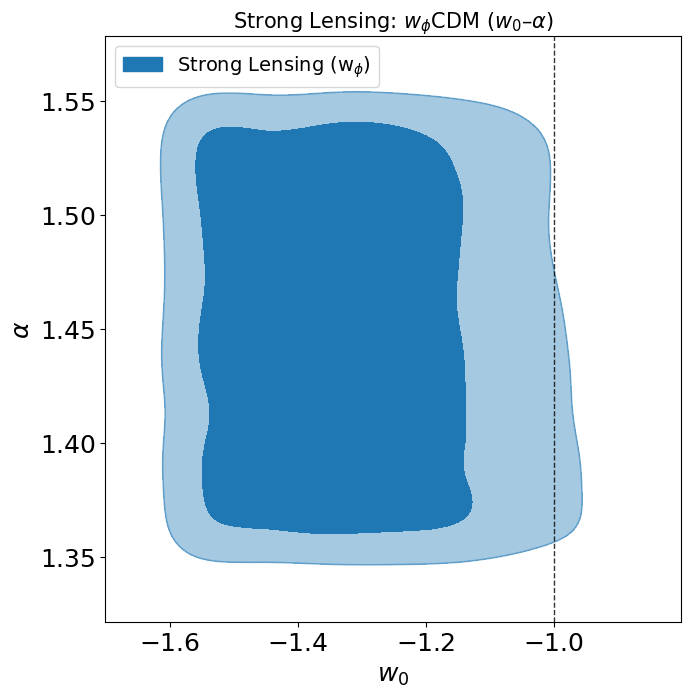

In [20]:
# pip install getdist matplotlib scipy
import os, numpy as np
import matplotlib.pyplot as plt
from getdist.mcsamples import MCSamples
from getdist import plots

# ====================== 基础路径（按需修改） ======================
base_dir       = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
local_pairs    = [("linear", "wphi-0.22")]   # 本地 3D 链（含 omegam, w0, alpha）
local_col_idx  = {'omegam': 0, 'w0': 1, 'alpha': 2}
burnin_frac    = 0.30

# ====================== 工具函数 ======================
def numpy3d_to_mcsamples_w0_alpha(arr, burnin_frac=0.3, col_idx=None, label=None):
    """
    从 (nwalk, nstep, ndim) 或 (N, ndim) 的数组中抽取 (w0, alpha) → MCSamples
    """
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr

    iw0 = col_idx['w0']; ialp = col_idx['alpha']
    sub  = flat[:, [iw0, ialp]]
    mcs = MCSamples(samples=sub, names=['w0','alpha'], labels=[r'w_0', r'\alpha'])
    if label: mcs.label = label
    mcs.updateSettings({'ignore_rows': 0.0})
    return mcs

def auto_limits_1d(samples_list, name, q=(0.5, 99.5), pad=0.15):
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals: return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:,0]), np.max(vals[:,1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

# ====================== 加载本地 SL 链（仅一次） ======================
evo, prior = local_pairs[0]
f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop3D-{evo}-{prior}.npy")
if not os.path.isfile(f):
    raise FileNotFoundError(f"找不到本地链文件: {f}")

arr = np.load(f)
SL_w0a = numpy3d_to_mcsamples_w0_alpha(arr, burnin_frac=burnin_frac,
                                       col_idx=local_col_idx, label=r"Strong Lensing (w$_\phi$)")
# ====================== 绘图（仅 Strong Lensing: w0–alpha） ======================
g = plots.get_subplot_plotter(width_inch=6.8)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 18
g.settings.legend_fontsize = 14

# 画 SL 的 w0–alpha 轮廓（可选 filled=True/False）
g.plot_2d(SL_w0a, ['w0','alpha'], filled=True, colors=['#1f77b4'])

ax = g.subplots[0, 0]
xlim = auto_limits_1d([SL_w0a], 'w0')     or (-1.6, -0.6)
ylim = auto_limits_1d([SL_w0a], 'alpha')  or (1.0, 2.0)
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_xlabel(r'$w_0$', fontsize=18)
ax.set_ylabel(r'$\alpha$', fontsize=18)
ax.set_title(r'Strong Lensing: $w_\phi$CDM ($w_0$–$\alpha$)', fontsize=15)

# 参考线：ΛCDM (w0=-1)（可选）
ax.axvline(-1.0, ls='--', lw=1.0, color='k', alpha=0.8)

g.add_legend([SL_w0a.label], legend_loc='best', colored_text=False)

out = "SL_wphi_w0_alpha.png"
g.export(out)
print(f"Saved plot: {out}")


In [21]:
# === 1D summaries for (omegam, w0, alpha) in wphi scenario ===
import numpy as np
from scipy.stats import gaussian_kde

# ---------- weighted helpers ----------
def _normalize_weights(w):
    if w is None: return None
    w = np.asarray(w, float); s = np.sum(w)
    if s <= 0 or not np.isfinite(s): return None
    return w / s

def _weighted_quantile(x, q, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.quantile(x, q)
    w = np.asarray(w, float)
    s = np.argsort(x)
    xs, ws = x[s], w[s]
    cdf = np.cumsum(ws) / np.sum(ws)
    return np.interp(q, cdf, xs)

def _weighted_quantiles(x, qs, w=None):
    qs = np.atleast_1d(qs).astype(float)
    return np.array([_weighted_quantile(x, q, w) for q in qs])

def _weighted_median(x, w=None):
    return _weighted_quantile(x, 0.5, w)

def _weighted_mad(x, w=None, scale=1.4826):
    med = _weighted_median(x, w)
    return scale * _weighted_median(np.abs(x - med), w)

def _oned_peak(x, w=None, grids=2048):
    x = np.asarray(x, float)
    xmin, xmax = np.min(x), np.max(x)
    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin == xmax:
        return float(np.median(x))
    grid = np.linspace(xmin, xmax, grids)
    kde  = gaussian_kde(x, weights=_normalize_weights(w)) if w is not None else gaussian_kde(x)
    dens = kde(grid)
    return float(grid[np.argmax(dens)])

def _weighted_mean_sigma(x, w=None):
    x = np.asarray(x, float)
    if w is None:
        return float(np.mean(x)), float(np.std(x, ddof=0))
    wn = _normalize_weights(w)
    mu = float(np.sum(wn * x))
    sig = float(np.sqrt(np.sum(wn * (x - mu)**2)))
    return mu, sig

# ---------- alias-aware getters ----------
_ALIAS = {
    'omegam': ['omegam','om','Omega_m','OmegaM','omm'],
    'w0'    : ['w0','w','w_0'],
    'alpha' : ['alpha','a']  # 可按需扩展别名
}

def _get_param_array_with_alias(mcs, target):
    # 先从已注册名里找
    names = [p.name for p in mcs.getParamNames().names]
    if target in names:
        P = mcs.getParams()
        return np.asarray(getattr(P, target), float)
    # 尝试别名
    for alt in _ALIAS.get(target, []):
        if alt in names:
            P = mcs.getParams()
            return np.asarray(getattr(P, alt), float)
    # 兜底：有时属性存在但未在 names 里注册
    P = mcs.getParams()
    for alt in _ALIAS.get(target, []):
        if hasattr(P, alt):
            return np.asarray(getattr(P, alt), float)
    return None

# ---------- summarize & print ----------
def summarize_mcs_1dset(mcs, names=('omegam','w0','alpha')):
    out = {}
    wts = None if mcs.weights is None else np.asarray(mcs.weights, float)
    for nm in names:
        arr = _get_param_array_with_alias(mcs, nm)
        if arr is None:
            out[nm] = None
            continue
        mean, sigma = _weighted_mean_sigma(arr, wts)
        med  = _weighted_median(arr, wts)
        mad  = _weighted_mad(arr, wts)
        pk   = _oned_peak(arr, wts)
        q16, q84 = _weighted_quantiles(arr, [0.16, 0.84], wts)
        out[nm] = dict(
            mean=mean, sigma=sigma,
            median=med, mad=mad,
            peak=pk, q16=q16, q84=q84,
            dmed_minus=med-q16, dmed_plus=q84-med
        )
    return out

def print_summary_1d(tag, summ, names=('omegam','w0','alpha')):
    print(f"\n=== {tag} ===")
    for nm in names:
        s = summ.get(nm, None)
        if s is None:
            print(f"{nm:7s}: (N/A)")
            continue
        peak_txt   = f"peak = {s['peak']:.6f}"
        median_txt = (f"median = {s['median']:.6f} "
                      f"(q16={s['q16']:.6f}, q84={s['q84']:.6f}; "
                      f"Δ-={s['dmed_minus']:.6f}, Δ+={s['dmed_plus']:.6f}) "
                      f"(MAD={s['mad']:.6f})")
        mean_txt   = f"mean = {s['mean']:.6f}, sigma = {s['sigma']:.6f}"
        print(f"{nm:7s}: {peak_txt} | {median_txt} | {mean_txt}")

# ---------- run on your objects ----------
targets = [
    (SL_w0a.label, SL_w0a),
    # (BAO.label,           BAO),
    # (planck_bao.label,    planck_bao),
    # (SLxBAO.label,        SLxBAO),
    # (SLxPlanckBAO.label,  SLxPlanckBAO),
]
for tag, mcs in targets:
    s = summarize_mcs_1dset(mcs, names=('omegam','w0','alpha'))
    print_summary_1d(tag, s, names=('omegam','w0','alpha'))



=== Strong Lensing (w$_\phi$) ===
omegam : (N/A)
w0     : peak = -1.310583 | median = -1.322467 (q16=-1.506935, q84=-1.131956; Δ-=0.184468, Δ+=0.190511) (MAD=0.198099) | mean = -1.315480, sigma = 0.169247
alpha  : peak = 1.430999 | median = 1.448173 (q16=1.381606, q84=1.516416; Δ-=0.066567, Δ+=0.068243) (MAD=0.073837) | mean = 1.448917, sigma = 0.057497
